# mini BERT 만들기

BERT를 pretrain하는 전체 과정을 직접 해보는 프로젝트다. MLM과 NSP 데이터를 만들고, BERT 인코더를 구현한 다음 pretrain까지 진행한다. 이번엔 vocab size를 8000으로 줄이고 전체 파라미터가 1M 수준인 작은 mini BERT를 만들어서 10 epoch 학습시킨다.

## 라이브러리 버전 확인 및 설치

In [ ]:
!pip install -q sentencepiece tqdm torchinfo

In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os, re, math, random, collections, json, shutil, zipfile, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

print("torch:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

torch: 2.11.0+cu128
device: cuda


## 데이터 다운로드

한글 나무위키/위키 코퍼스(`kowiki.txt`)를 받는다. Colab 기준 경로로 진행한다.

In [ ]:
!mkdir -p /content/data
!mkdir -p /content/models
!wget -q https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip -O /content/data/kowiki.txt.zip
!cd /content/data && unzip -o kowiki.txt.zip

Archive:  kowiki.txt.zip
  inflating: kowiki.txt              


## 1. Tokenizer 준비

SentencePiece로 vocab_size 8000짜리 토크나이저를 만든다. 학습 노드에서는 32000이었는데, mini BERT는 파라미터를 1M로 줄여야 해서 vocab도 8000으로 줄였다.

BERT에 쓰이는 특수토큰 [MASK], [SEP], [CLS]가 vocab에 포함되도록 user_defined_symbols로 넣어준다. 이 토큰들로 문장 경계나 마스킹을 표현할 수 있다.

In [ ]:
corpus_file = '/content/data/kowiki.txt'
prefix = '/content/models/ko_8000'
vocab_size = 8000

spm.SentencePieceTrainer.train(
    f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7}"
    " --model_type=bpe --max_sentence_length=999999"
    " --pad_id=0 --pad_piece=[PAD]"
    " --unk_id=1 --unk_piece=[UNK]"
    " --bos_id=2 --bos_piece=[BOS]"
    " --eos_id=3 --eos_piece=[EOS]"
    " --user_defined_symbols=[SEP],[CLS],[MASK]"
)

In [ ]:
vocab = spm.SentencePieceProcessor()
vocab.load(f"{prefix}.model")
print("vocab size:", len(vocab))

vocab size: 8007


토크나이저가 잘 만들어졌는지, 특수토큰 7개를 제외한 나머지 vocab을 확인해본다.

In [ ]:
# 특수 token 7개를 제외한 나머지 token들
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))
print("일반 vocab 개수:", len(vocab_list))
print(vocab_list[:20])

일반 vocab 개수: 8000
['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아']


## 2. 데이터 전처리 (1) MASK 생성

BERT의 MLM은 GPT처럼 "다음 단어"를 맞히는 게 아니라, 문장 중간을 [MASK]로 가리고 그 빈칸에 들어갈 단어를 맞히는 방식이다. 전체 토큰의 15%를 마스킹 대상으로 고르고, 그중 80%는 [MASK], 10%는 랜덤 토큰, 10%는 원래 토큰 그대로 둔다.

create_pretrain_mask()는 서브워드가 아니라 띄어쓰기 단위로 마스킹한다. 서브워드 하나만 가리면 너무 쉽게 맞혀버리니까, 단어 전체를 가려야 학습에 의미가 있다.

In [ ]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    :param tokens: 토큰 리스트
    :param mask_cnt: 마스킹할 개수 (전체의 15%)
    :param vocab_list: 랜덤 토큰용 vocab
    :return tokens: 마스킹된 토큰, mask_idx: 마스킹 위치, mask_label: 원래 값
    """
    # 단어(띄어쓰기) 단위로 묶어서 마스킹하려고 index를 분할한다.
    # ▁(U+2581)로 시작하면 새 단어, 아니면 이전 단어에 붙는 서브워드다.
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)  # 랜덤하게 마스킹 대상 선택
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            # 80% [MASK] / 10% 원래토큰 / 10% 랜덤토큰
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]
    return tokens, mask_idx, mask_label

## 3. 데이터 전처리 (2) NSP pair 생성

NSP는 문장 A 뒤에 문장 B가 실제로 이어지는지(is_next=1) 아닌지(is_next=0)를 맞히는 task다. 두 문장을 짝지어서 50% 확률로 순서를 뒤바꿔 true/false 케이스를 만든다.

[CLS] 문장A [SEP] 문장B [SEP] 형태로 만들고, segment는 첫 문장 부분을 0, 둘째 문장 부분을 1로 채운다. 두 문장 길이 합이 최대 길이를 넘으면 trim_tokens()로 잘라낸다.

In [ ]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """두 문장 길이 합이 max_seq를 넘으면, 더 긴 쪽을 하나씩 줄인다."""
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]     # A는 앞에서 제거
        else:
            tokens_b.pop()      # B는 뒤에서 제거

In [ ]:
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """doc(문단) 하나로부터 MLM+NSP가 결합된 pretrain 인스턴스들을 생성한다."""
    max_seq = n_seq - 3  # [CLS], [SEP], [SEP] 3개 자리 확보

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            # chunk를 임의 지점에서 A/B로 나눔
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 50% 확률로 A/B 순서를 뒤바꿔서 NSP의 false(is_next=0) 케이스를 만든다
            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            # segment: 첫 문장(+CLS,SEP)은 0, 둘째 문장(+SEP)은 1
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            # MLM 마스킹까지 여기서 함께 적용 -> MLM/NSP 데이터가 한 인스턴스로 결합
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instances.append({
                "tokens": tokens, "segment": segment, "is_next": is_next,
                "mask_idx": mask_idx, "mask_label": mask_label
            })
            current_chunk = []
            current_length = 0
    return instances

## 4. 데이터 전처리 (3) 데이터셋 완성

전체 코퍼스로 pretrain 데이터를 만들어 json으로 저장한다. 데이터셋 크기가 커서, 로딩할 때는 np.memmap을 써서 메모리에 다 올리지 않고 디스크 기반으로 처리한다.

In [ ]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """코퍼스 전체 -> pretrain json 생성"""
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개 제외 vocab_list (랜덤 토큰용)
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))

    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":            # 빈 줄 = 새 문단 경계
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):
                save_pretrain_instances(out_f, doc)

In [ ]:
pretrain_json_path = '/content/data/bert_pre_train.json'
make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

  0%|          | 0/3957761 [00:00<?, ?it/s]

In [ ]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """json -> np.memmap 로딩. count로 로딩 개수 제한 가능."""
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            if count is not None and count <= total:
                break

    # np.memmap은 디스크 기반 배열이라 적은 메모리로도 대용량 데이터를 처리할 수 있다
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments   = np.memmap(filename='segments.memmap',   mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                break
            data = json.loads(line)
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            label_nsp = data["is_next"]
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)  # 비마스크 위치는 0(=무시)
            label_mlm[mask_idx] = mask_label
            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq
            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [ ]:
# 전체를 다 올리면 무거우니 128,000건만 로딩해서 사용
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)
print("enc_tokens:", pre_train_inputs[0].shape)

  0%|          | 0/128000 [00:00<?, ?it/s]

enc_tokens: (128000, 128)


## 5. BERT 모델 구현

BERT는 Transformer Encoder로 이루어진다. GPT(decoder-only)와 반대로 BERT는 양방향 self-attention을 쓰는데, 마스킹된 단어를 맞히려면 앞뒤 문맥을 다 봐야 하니까 causal mask 없이 패딩만 가린다.

또 Transformer와 달리 임베딩이 3개다. Token, Position에 더해 Segment 임베딩이 있는데, 이건 토큰이 문장 A인지 B인지 구분하는 용도다. Position 임베딩은 Transformer의 sin/cos 고정 인코딩과 달리 학습되는 임베딩이다.

In [ ]:
def get_pad_mask(tokens, i_pad=0):
    """패딩 위치를 1로 표시 (attention에서 무시할 자리)"""
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def gelu(x):
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

In [ ]:
class SharedEmbedding(nn.Module):
    """Token 임베딩 + 출력 projection을 하나의 가중치로 공유(weight tying)하는 레이어."""
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        # 이 행렬 하나를 입력 임베딩(lookup)과 출력 logit 계산에 같이 쓴다 (weight tying).
        # vocab이 파라미터의 대부분인 mini BERT에서 파라미터를 줄이는 핵심.
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)  # 같은 행렬을 transpose해서 재사용
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)
        return outputs

class PositionEmbedding(nn.Module):
    """학습되는 위치 임베딩 (Transformer의 sin/cos 고정 인코딩과 다름)"""
    def __init__(self, config, name="position_embedding"):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1  # 0,1,2,... 위치 인덱스
        position = position.long()
        return self.embedding(position)

In [ ]:
class ScaleDotProductAttention(nn.Module):
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()
    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        # 마스크(=1인 자리)에 큰 음수를 빼주면 softmax 후 확률이 0에 가까워진다
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        return torch.matmul(attn_prob, V)

class MultiHeadAttention(nn.Module):
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()
        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)
    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, -1, self.n_head * self.d_head)
        return self.W_O(attn_out)

class PositionWiseFeedForward(nn.Module):
    def __init__(self, config, name="feed_forward"):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU()   # BERT는 ReLU 대신 GELU 사용
    def forward(self, inputs):
        return self.W_2(self.gelu(self.W_1(inputs)))

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, config, name="encoder_layer"):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, enc_embed, self_mask):
        # Post-LN 구조: sub-layer 결과에 residual 더하고 norm
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))
        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))
        return enc_out

class BERT(nn.Module):
    def __init__(self, config):
        super(BERT, self).__init__()
        self.i_pad = config.i_pad
        # BERT의 3가지 임베딩: Token + Position + Segment
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, enc_tokens, segments):
        # causal mask 없이 패딩만 가린다 (양방향 attention)
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)
        enc_out = self.dropout(self.get_embedding(enc_tokens, segments))
        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)
        logits_cls = enc_out[:, 0]                              # [CLS] 토큰 -> NSP용
        logits_lm = self.embedding(enc_out, mode="linear")      # 전체 토큰 -> MLM용
        return logits_cls, logits_lm
    def get_embedding(self, tokens, segments):
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        return self.norm(embed)

In [ ]:
class PooledOutput(nn.Module):
    """[CLS] 표현 -> NSP 이진 분류 logit"""
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)
    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        return self.dense2(outputs)   # raw logits (CrossEntropyLoss가 softmax 처리)

class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)
    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()
        logits_cls, logits_lm = self.bert(enc_tokens, segments)
        outputs_nsp = self.pooled_output(logits_cls)
        outputs_mlm = logits_lm
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

### mini BERT config 설정 (파라미터 약 1M)

파라미터를 1M 근처로 맞추는 게 이번 프로젝트의 핵심 제약이다. mini BERT에서는 vocab 임베딩(n_vocab x d_model)이 전체 파라미터의 대부분을 차지한다. vocab이 8000으로 고정이니 d_model을 작게 잡아야 1M에 맞는다.

d_model=96일 때 약 1.13M이 나와서 이걸 골랐다. (d_model=64는 0.67M, 128은 1.65M) weight tying으로 vocab 행렬을 입력/출력이 공유하기 때문이다. 안 그랬으면 훨씬 커졌을 파라미터를 절반 가까이 아꼈다.

In [ ]:
config = Config({
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,           # d_model / n_head
    "d_ff": 384,            # d_model * 4
    "dropout": 0.1,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 128,
    "n_vocab": 8000,
    "i_pad": 0,
})

pre_train_model = build_model_pre_train(config).to(device)
n_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)
print(f"전체 파라미터 수: {n_params:,} ({n_params/1e6:.2f}M)")

전체 파라미터 수: 1,125,696 (1.13M)


In [ ]:
from torchinfo import summary
summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)],
        dtypes=[torch.long, torch.long])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 96]                  --
│    └─SharedEmbedding: 2-1                                  [10, 128, 96]             768,000
│    └─PositionEmbedding: 2-2                                [10, 128, 96]             --
│    │    └─Embedding: 3-1                                   [10, 128, 96]             12,288
│    └─Embedding: 2-3                                        [10, 128, 96]             192
│    └─LayerNorm: 2-4                                        [10, 128, 96]             192
│    └─Dropout: 2-5                                          [10, 128, 96]             --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 96]          

## 6. pretrain 진행

loss/accuracy 함수를 정의하고 warmup + cosine decay 스케줄러로 10 epoch 학습한다.

MLM loss는 마스킹된 위치(pad이 아닌 곳)에 대해서만 계산하고, MLM을 더 강하게 학습시키려고 20배 스케일한다. LR 스케줄러는 warmup으로 천천히 올렸다가 cosine으로 감소시키는데, 선언만 하지 말고 매 스텝 optimizer의 lr을 실제로 갱신해줘야 한다.

In [ ]:
def lm_loss(y_true, y_pred):
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    mask = (y_true != 0).float().view(-1)  # pad(0) 위치 제외 (loss와 같은 1D shape로)
    loss = loss * mask
    return loss.sum() / mask.sum().clamp(min=1) * 20   # 마스크된 위치 평균 * 20 (MLM 강조)

def lm_acc(y_true, y_pred):
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    mask = (y_true != 0).float()
    matches *= mask
    return matches.sum() / mask.sum().clamp(min=1)

In [ ]:
class CosineSchedule:
    """warmup 후 cosine 형태로 감소하는 LR 스케줄"""
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0
    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr
    def step(self):
        self.step_num += 1
        return self.get_lr()

In [ ]:
epochs = 10
batch_size = 64
model_dir = '/content/models'

# 데이터를 텐서로 변환
pre_train_inputs = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
pre_train_labels = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

train_dataset = TensorDataset(pre_train_inputs[0], pre_train_inputs[1],
                              pre_train_labels[0], pre_train_labels[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)
learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)   # pad/비마스크 위치 제외

train_steps: 20000


In [ ]:
history = {'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = total_nsp_loss = total_mlm_loss = 0
    total_nsp_acc = total_mlm_acc = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))
        loss = loss_nsp + loss_mlm

        loss.backward()
        optimizer.step()
        # LR 스케줄러를 실제로 optimizer에 반영 (빠뜨리면 고정 lr로 학습된다)
        lr = learning_rate_scheduler.step()
        for g in optimizer.param_groups:
            g['lr'] = lr

        total_loss += loss.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_mask = (labels_mlm_batch != 0)
        mlm_acc = ((logits_mlm.argmax(dim=-1) == labels_mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)
        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    n = len(train_dataloader)
    history['nsp_loss'].append(total_nsp_loss / n)
    history['mlm_loss'].append(total_mlm_loss / n)
    history['nsp_acc'].append(total_nsp_acc / n)
    history['mlm_acc'].append(total_mlm_acc / n)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/n:.4f} | "
          f"NSP Loss: {total_nsp_loss/n:.4f}, MLM Loss: {total_mlm_loss/n:.4f} | "
          f"NSP Acc: {total_nsp_acc/n:.4f}, MLM Acc: {total_mlm_acc/n:.4f}")

    torch.save(pre_train_model.state_dict(), f"{model_dir}/bert_pre_train_epoch_{epoch+1}.pt")

Epoch 1/10 - Loss: 8.3804 | NSP Loss: 0.6219, MLM Loss: 7.7585 | NSP Acc: 0.5947, MLM Acc: 0.0256
Epoch 2/10 - Loss: 7.9981 | NSP Loss: 0.5929, MLM Loss: 7.4052 | NSP Acc: 0.5932, MLM Acc: 0.0289
Epoch 3/10 - Loss: 7.9224 | NSP Loss: 0.5874, MLM Loss: 7.3350 | NSP Acc: 0.5965, MLM Acc: 0.0320
Epoch 4/10 - Loss: 7.7918 | NSP Loss: 0.5842, MLM Loss: 7.2076 | NSP Acc: 0.6007, MLM Acc: 0.0380
Epoch 5/10 - Loss: 7.6028 | NSP Loss: 0.5790, MLM Loss: 7.0238 | NSP Acc: 0.6140, MLM Acc: 0.0467
Epoch 6/10 - Loss: 7.4510 | NSP Loss: 0.5689, MLM Loss: 6.8821 | NSP Acc: 0.6217, MLM Acc: 0.0561
Epoch 7/10 - Loss: 7.3431 | NSP Loss: 0.5608, MLM Loss: 6.7823 | NSP Acc: 0.6242, MLM Acc: 0.0649
Epoch 8/10 - Loss: 7.2794 | NSP Loss: 0.5570, MLM Loss: 6.7223 | NSP Acc: 0.6294, MLM Acc: 0.0706
Epoch 9/10 - Loss: 7.2470 | NSP Loss: 0.5554, MLM Loss: 6.6915 | NSP Acc: 0.6302, MLM Acc: 0.0734
Epoch 10/10 - Loss: 7.2356 | NSP Loss: 0.5545, MLM Loss: 6.6811 | NSP Acc: 0.6313, MLM Acc: 0.0745


## 7. 프로젝트 결과 (시각화)

NSP/MLM의 loss와 accuracy를 epoch별로 그려서 학습이 안정적으로 진행됐는지 확인한다. 모델이 워낙 작아서(1M) loss가 완벽하게 수렴하진 않아도, 하락 추세가 꾸준하면 정상적으로 학습되고 있다고 볼 수 있다.

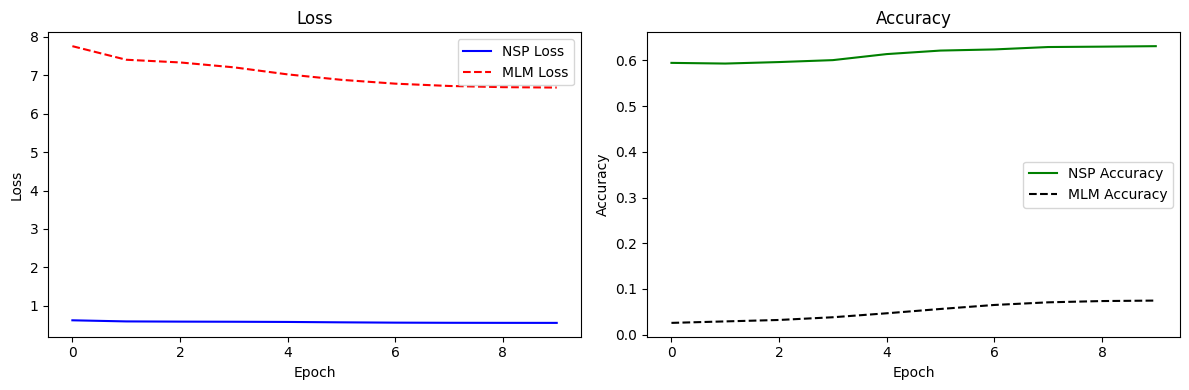

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy')

plt.tight_layout()
plt.show()

## 회고

파라미터를 1M로 맞추는 과정에서 vocab 임베딩이 전체 파라미터의 대부분을 차지한다는 걸 알게 됐다. weight tying으로 입력/출력 임베딩을 공유하는 게 단순한 최적화가 아니라, 작은 모델에서는 파라미터 예산을 지키는 핵심 장치였다. 이번 퀘스트에서는 d_model=96으로 1.13M을 맞췄다.

BERT가 GPT와 달리 양방향 attention(causal mask 없음)을 쓰는 이유가, MLM에서 마스킹된 단어를 앞뒤 문맥으로 맞혀야 하기 때문이라는 걸 마스크 구현부에서 확인했다.

학습 결과를 보면 10 epoch 동안 전체 loss가 8.38에서 7.24까지 꾸준히 떨어졌다. NSP loss(0.62 -> 0.55)와 MLM loss(7.76 -> 6.68) 둘 다 안정적으로 감소했고, NSP accuracy는 0.59에서 0.63까지 올랐다. 다만 MLM accuracy는 0.07 수준으로 낮은데, vocab이 8000이고 모델이 1M밖에 안 되는 한계 때문인것 같다. 8000개 중 하나를 정확히 맞히는 건 이 정도 크기 모델에는 어려운 task라, 정답률 보다는 loss가 꾸준히 내려간다는 것 자체를 통해 학습이 제대로 되고 있다는 점으로 만족해야 할것 같다. epoch을 더 늘리거나 모델을 키우면 MLM accuracy도 더 오를 여지가 있어 보인다.